# Import thư viện

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.8 MB/s eta 0:00:00


In [4]:

import glob
import os
import cv2
import numpy as np
import random
import shutil
import yaml
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from ultralytics import YOLO
import tensorflow as tf

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Đọc và xử lý dữ liệu

### Đọc dữ liệu

In [29]:
%cd /content/drive/MyDrive/Job/KneeOA/

/content/drive/MyDrive/Job/KneeOA


In [30]:
class Config():
    # Đường dẫn đến dữ liệu gốc
    IMAGES_DIR = './datasets/images'
    LABELS_DIR = './datasets/labels'
    LABELS_DIR_RM_CLASS = './datasets/Labels_rm_class_0'

    AUGMENT_IMAGES = './datasets/augmented_images'
    AUGMENT_LABELS = './datasets/augmented_labels'

    # Đường dẫm đến dữ liệu đã được xử lý
    PROCESSING_IMAGES_DIR = './datasets/processing_images'
    PROCESSING_LABELS_DIR = './datasets/processing_labels'

    # Đường dẫn đến folder TRAIN, VAL, TEST
    FOLDER_TRAIN_PATH = './datasets/train'
    FOLDER_VAL_PATH = './datasets/val'
    FOLDER_TEST_PATH = './datasets/test'

    # Đường dẫn đến các folder chứa ảnh
    FOLDER_TRAIN_IMG = os.path.join(FOLDER_TRAIN_PATH, "images")
    FOLDER_VAL_IMG = os.path.join(FOLDER_VAL_PATH, "images")
    FOLDER_TEST_IMG = os.path.join(FOLDER_TEST_PATH, "images")

    # Đường dẫn đến các folder chứa nhãn
    FOLDER_TRAIN_LAB = os.path.join(FOLDER_TRAIN_PATH, "labels")
    FOLDER_VAL_LAB = os.path.join(FOLDER_VAL_PATH, "labels")
    FOLDER_TEST_LAB = os.path.join(FOLDER_TEST_PATH, "labels")

    # Đường dẫn đến file weight YOLO
    WEIGHT_YOLO = './weight/yolo11l.pt'

    # Đường dẫn đến file custom dữ liệu
    DATA_CUSTOM = './weight/custom_data.yaml'

    # Nhãn dữ liệu
    LABELS_NAME = ['lv_1', 'lv_2', 'lv_3', 'lv_4']
    LABELS_NAME_2 = ['lv_1_a', 'lv_1_b', 'lv_2_a','lv_b', 'lv_3_a', 'lv_3_b', 'lv_4_a', 'lv_4_b']

In [8]:
def remove_class_0_from_labels(source_dir, target_dir):
    # Tạo thư mục đích nếu chưa tồn tại
    os.makedirs(target_dir, exist_ok=True)

    # Duyệt qua tất cả các tệp trong thư mục nguồn
    for filename in os.listdir(source_dir):
        if filename.endswith('.txt'):
            source_path = os.path.join(source_dir, filename)
            target_path = os.path.join(target_dir, filename)

            filtered_lines = []
            with open(source_path, 'r') as f_read:
                for line in f_read:
                    parts = line.strip().split()
                    if parts and int(parts[0]) != 0:  # Giữ lại các nhãn không phải class 0
                        # Giảm class_id đi 1 để bỏ qua class 0
                        new_class_id = int(parts[0]) - 1
                        filtered_lines.append(f"{new_class_id} {' '.join(parts[1:])}\n")

            # Chỉ ghi tệp nếu có nhãn sau khi lọc
            if filtered_lines:
                with open(target_path, 'w') as f_write:
                    f_write.writelines(filtered_lines)
            # else: # Optional: Nếu muốn xóa các file không có nhãn sau khi lọc
            #     print(f"File {filename} không còn nhãn sau khi loại bỏ class 0, không tạo tệp mới.")


In [ ]:
# Gọi hàm để xử lý nhãn
remove_class_0_from_labels(Config.LABELS_DIR, Config.LABELS_DIR_RM_CLASS)

### Kiểm tra so khớp ảnh và nhãn

In [9]:
def check_data(folder_img, folder_lab, folder_unmatched):
    # Tạo thư mục chứa các tệp không có tương ứng nếu chưa tồn tại
    os.makedirs(folder_unmatched, exist_ok=True)

    # Các định dạng ảnh phổ biến
    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

    # Lấy danh sách tệp ảnh và nhãn, bỏ phần mở rộng
    img_files = {}
    for f in os.listdir(folder_img):
        name, ext = os.path.splitext(f)
        if ext.lower() in img_extensions:
            img_files[name] = ext.lower()  # Lưu cả phần mở rộng

    lab_files = {os.path.splitext(f)[0] for f in os.listdir(folder_lab) if f.endswith('.txt')}

    # Tìm các tệp không có tương ứng
    img_not_in_lab = set(img_files.keys()) - lab_files
    lab_not_in_img = lab_files - set(img_files.keys())

    # Di chuyển các tệp ảnh không có nhãn tương ứng
    if img_not_in_lab:
        print("Các tệp ảnh không có nhãn tương ứng:")
        for img in img_not_in_lab:
            print(img)
            src_img = os.path.join(folder_img, img + img_files[img])  # Lấy đúng phần mở rộng
            dest_img = os.path.join(folder_unmatched, img + img_files[img])
            if os.path.exists(src_img):
                shutil.move(src_img, dest_img)

    # Di chuyển các tệp nhãn không có ảnh tương ứng
    if lab_not_in_img:
        print("Các tệp nhãn không có ảnh tương ứng:")
        for lab in lab_not_in_img:
            print(lab)
            src_lab = os.path.join(folder_lab, lab + '.txt')
            dest_lab = os.path.join(folder_unmatched, lab + '.txt')
            if os.path.exists(src_lab):
                shutil.move(src_lab, dest_lab)

### Phân tích dữ liệu

In [10]:
def count_labels(folder_path, label_order):
    # Khởi tạo một dictionary để đếm số lượng của mỗi nhãn, giá trị ban đầu là 0 cho tất cả nhãn
    label_counts = {label: 0 for label in label_order}

    # Duyệt qua tất cả các file trong thư mục chứa nhãn
    for file_name in os.listdir(folder_path):
        # Chỉ xử lý các file có định dạng .txt (file chứa nhãn)
        if file_name.endswith('.txt'):
            # Mở file nhãn và đọc nội dung
            with open(os.path.join(folder_path, file_name), 'r') as file:
                lines = file.readlines()

                # Duyệt qua từng dòng trong file nhãn (mỗi dòng tương ứng với một nhãn trong ảnh)
                for line in lines:
                    # Lấy chỉ số nhãn (class_id), đó là số đầu tiên trong dòng
                    label_index = int(line.split()[0])

                    # Tra nhãn từ chỉ số nhãn dựa trên danh sách `label_order`
                    label = label_order[label_index]

                    # Nếu nhãn tồn tại trong label_counts, tăng số đếm của nhãn đó
                    if label in label_counts:
                        label_counts[label] += 1

    return label_counts

### Cân bằng dữ liệu

In [11]:
# Hàm để lật ngang ảnh và cập nhật bounding box
def flip_image_and_labels(image, labels):
    flipped_image = cv2.flip(image, 1)  # Lật ngang ảnh

    flipped_labels = []
    for label in labels:
        class_id, x_center, y_center, width, height = map(float, label.split())
        # Điều chỉnh tọa độ x_center cho ảnh lật ngang
        x_center_flipped = 1.0 - x_center  # Đảo ngược x_center
        flipped_labels.append(f"{int(class_id)} {x_center_flipped:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return flipped_image, flipped_labels

In [12]:
# Hàm để cân bằng dữ liệu
def balance_data(image_folder, label_folder, target_image_folder, target_label_folder, label_counts, label_order, max_samples):
    if os.path.exists(target_image_folder):
        shutil.rmtree(target_image_folder)
    if os.path.exists(target_label_folder):
        shutil.rmtree(target_label_folder)
    os.makedirs(target_image_folder, exist_ok=True)
    os.makedirs(target_label_folder, exist_ok=True)

    current_counts = label_counts.copy()

    for label in label_order:
        needed_samples = max_samples - current_counts[label]
        if needed_samples <= 0:
            continue

        images_with_label = []
        for label_file in os.listdir(label_folder):
            if label_file.endswith('.txt'):
                label_path = os.path.join(label_folder, label_file)
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    # Chỉ thêm ảnh chứa ít nhất một nhãn liên quan
                    if any(int(line.split()[0]) == label_order.index(label) for line in lines):
                        image_name = label_file.replace('.txt', '.jpg')
                        image_path = os.path.join(image_folder, image_name)
                        if os.path.exists(image_path):
                            images_with_label.append((image_path, label_path))

        if not images_with_label:
            print(f"Không tìm thấy ảnh nào cho nhãn {label} để tăng cường.")
            continue

        random.shuffle(images_with_label)
        i = 0
        img_idx = 0

        while i < needed_samples:
            image_path, label_path = images_with_label[img_idx % len(images_with_label)]
            img_idx += 1

            # Đọc ảnh và nhãn
            image = cv2.imread(image_path)
            with open(label_path, 'r') as f:
                lines = f.readlines()

            # Chỉ giữ lại nhãn liên quan
            relevant_labels = [line for line in lines if int(line.split()[0]) == label_order.index(label)]

            if not relevant_labels:
                continue

            # Lật ngang ảnh và điều chỉnh nhãn
            flipped_image, flipped_labels = flip_image_and_labels(image, relevant_labels)

            # Lưu ảnh đã tăng cường
            base_image_name = os.path.splitext(os.path.basename(image_path))[0]
            target_image_name = f"{base_image_name}_flip_{i}.jpg"
            target_image_path = os.path.join(target_image_folder, target_image_name)

            cv2.imwrite(target_image_path, flipped_image)

            # Lưu nhãn đã điều chỉnh
            target_label_name = f"{os.path.splitext(os.path.basename(label_path))[0]}_flip_{i}.txt"
            target_label_path = os.path.join(target_label_folder, target_label_name)

            with open(target_label_path, 'w') as f_label:
                f_label.writelines(f"{line}\n" for line in flipped_labels)

            # Cập nhật số lượng đối tượng
            current_counts[label] += len(relevant_labels)
            i += len(relevant_labels)

            if current_counts[label] >= max_samples:
                break

### Gộp dữ liệu

In [13]:
def move_files(source_folder, target_folder, file_extension):
    for file_name in os.listdir(source_folder):
        if file_name.endswith(file_extension):
            src_path = os.path.join(source_folder, file_name)
            dst_path = os.path.join(target_folder, file_name)

            # Kiểm tra nếu file chưa tồn tại trong thư mục đích
            if not os.path.exists(dst_path):
                try:
                    shutil.move(src_path, dst_path)
                except Exception as e:
                    print(f"Không thể di chuyển {src_path}: {e}")
            else:
                print(f"File {file_name} đã tồn tại trong thư mục đích, bỏ qua.")

def move_folders(folder1_images, folder1_labels, folder2_images, folder2_labels):
    # Di chuyển ảnh
    move_files(folder1_images, folder2_images, '.jpg')
    if os.path.exists(folder1_images):
        shutil.rmtree(folder1_images)

    # Di chuyển nhãn
    move_files(folder1_labels, folder2_labels, '.txt')
    if os.path.exists(folder1_labels):
        shutil.rmtree(folder1_labels)

### Xử lý dữ liệu

In [14]:
# Đọc dữ liệu
def load_data(image_folder, label_folder):
    image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))]
    label_files = [os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.txt')]
    image_files.sort()
    label_files.sort()
    return image_files, label_files

In [15]:
# Đọc ảnh dưới dạng grayscale (1 kênh)
def load_grayscale_image(image_path):
    # Đọc ảnh trực tiếp dưới dạng grayscale (1 kênh)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Không thể đọc ảnh từ {image_path}")
    return image

# Resize ảnh, đảm bảo giữ đúng 1 kênh
def resize_image(image, target_size=(640, 640)):
    image_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_CUBIC)
    return image_resized

# Bộ lọc Gaussian Blur
def gaussian_blur(image, kernel_size=(5, 5)):
    return cv2.GaussianBlur(image, kernel_size, 0)

# Cân bằng histogram (CLAHE)
def apply_clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(image)  # Áp dụng CLAHE trực tiếp lên ảnh grayscale
    return enhanced_image

# Hàm tiền xử lý ảnh (resize, khử nhiễu và cân bằng histogram)
def preprocess_image(image_path, target_size=(640, 640)):
    # Đọc ảnh ở định dạng grayscale (1 kênh)
    image = load_grayscale_image(image_path)

    # Resize ảnh và đảm bảo giữ đúng 1 kênh
    image_resized = resize_image(image, target_size)

    # Áp dụng Gaussian Blur (khử nhiễu)
    image_blurred = gaussian_blur(image_resized, kernel_size=(5, 5))

    # Áp dụng CLAHE (cân bằng histogram)
    enhanced_image = apply_clahe(image_blurred)

    # Đảm bảo ảnh có 1 kênh (grayscale) sau tất cả các bước tiền xử lý
    if len(enhanced_image.shape) == 3 and enhanced_image.shape[2] == 3:
        enhanced_image = cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2GRAY)

    return enhanced_image

In [16]:
def scale_bounding_box(bbox, original_size, new_size=(640, 640)):
    # bbox là dạng [x_center, y_center, width, height] dưới dạng tỷ lệ phần trăm
    x_center, y_center, width, height = bbox
    x_scale = new_size[0] / original_size[0]
    y_scale = new_size[1] / original_size[1]

    # Chuyển đổi từ tỷ lệ phần trăm sang pixel
    x_center_pixel = x_center * original_size[0]
    y_center_pixel = y_center * original_size[1]
    width_pixel = width * original_size[0]
    height_pixel = height * original_size[1]

    # Cân chỉnh tỷ lệ pixel theo ảnh mới
    x_center_scaled = x_center_pixel * x_scale
    y_center_scaled = y_center_pixel * y_scale
    width_scaled = width_pixel * x_scale
    height_scaled = height_pixel * y_scale

    # Chuyển đổi lại sang tỷ lệ phần trăm của ảnh mới
    x_center_new = x_center_scaled / new_size[0]
    y_center_new = y_center_scaled / new_size[1]
    width_new = width_scaled / new_size[0]
    height_new = height_scaled / new_size[1]

    return [x_center_new, y_center_new, width_new, height_new]

def process_labels(label_path, original_size, new_size=(640, 640)):
    with open(label_path, 'r') as file:
        lines = file.readlines()

    new_labels = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.split())
        scaled_bbox = scale_bounding_box([x_center, y_center, width, height], original_size, new_size)
        new_labels.append(f"{class_id} {' '.join(map(str, scaled_bbox))}\n")

    return new_labels

In [17]:
# Lưu ảnh grayscale dưới định dạng PNG (giữ 1 kênh)
def save_processed_data(images, labels, target_image_folder, target_label_folder):
    if os.path.exists(target_image_folder):
        shutil.rmtree(target_image_folder)
    if os.path.exists(target_label_folder):
        shutil.rmtree(target_label_folder)

    os.makedirs(target_image_folder, exist_ok=True)
    os.makedirs(target_label_folder, exist_ok=True)

    for image, label in zip(images, labels):
        # Kiểm tra nếu ảnh có 1 kênh (grayscale)
        if len(image.shape) == 2:  # Nếu là ảnh grayscale (1 kênh)
            grayscale_image = image
        else:
            # Nếu ảnh có nhiều kênh, chuyển nó thành ảnh grayscale
            grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Lưu ảnh dưới định dạng PNG với OpenCV (giữ 1 kênh)
        image_filename = os.path.splitext(os.path.basename(label[0]))[0] + '.png'  # Lưu ảnh dưới dạng PNG
        cv2.imwrite(os.path.join(target_image_folder, image_filename), grayscale_image)

        # Lưu nhãn
        label_filename = os.path.splitext(os.path.basename(label[0]))[0] + '.txt'
        with open(os.path.join(target_label_folder, label_filename), 'w') as file:
            file.writelines(label[1])

In [18]:
# Hàm tiền xử lý dữ liệu
def preprocess_data(image_folder, label_folder, target_image_folder, target_label_folder, target_size=(640, 640)):
    # Giả sử hàm load_data() sẽ trả về danh sách các đường dẫn tệp ảnh và nhãn
    image_files, label_files = load_data(image_folder, label_folder)

    processed_images = []
    processed_labels = []

    for image_path, label_path in zip(image_files, label_files):
        # Tiền xử lý ảnh
        processed_image = preprocess_image(image_path, target_size)
        processed_images.append(processed_image)

        # Lấy kích thước gốc của ảnh trước khi resize để điều chỉnh nhãn
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Đọc ảnh gốc ở định dạng grayscale
        original_size = original_image.shape[:2]

        # Điều chỉnh nhãn (giả sử process_labels() sẽ xử lý điều này)
        new_labels = process_labels(label_path, original_size, target_size)
        processed_labels.append((label_path, new_labels))

    # Lưu dữ liệu (giả sử hàm save_processed_data() sẽ lưu ảnh và nhãn đã xử lý)
    save_processed_data(processed_images, processed_labels, target_image_folder, target_label_folder)

# Chia dữ liệu và trực quan dữ liệu

### Chia dữ liệu

In [19]:
def data_split(images_dir, labels_dir, folder_train_img, folder_val_img, folder_test_img,
               folder_train_lab, folder_val_lab, folder_test_lab):
    def create_directories(directories):
        for directory in directories:
            if os.path.exists(directory):
                shutil.rmtree(directory)  # Xóa thư mục nếu đã tồn tại
            os.makedirs(directory, exist_ok=True)  # Tạo lại thư mục

    # Danh sách các thư mục cần tạo
    directories = [
        folder_train_img,
        folder_val_img,
        folder_test_img,
        folder_train_lab,
        folder_val_lab,
        folder_test_lab,
    ]

    # Gọi hàm để tạo thư mục
    create_directories(directories)

    # Lấy danh sách các tệp ảnh và nhãn
    img_files = sorted(os.listdir(images_dir))
    lab_files = sorted(os.listdir(labels_dir))

    # Đảm bảo số lượng ảnh và nhãn bằng nhau
    assert len(img_files) == len(lab_files), "Số lượng ảnh và nhãn không khớp"

    # Chia tệp thành các tập train, val và test
    train_img_files, test_img_files, train_lab_files, test_lab_files = train_test_split(
        img_files, lab_files, test_size=0.3, random_state=42
    )
    val_img_files, test_img_files, val_lab_files, test_lab_files = train_test_split(
        test_img_files, test_lab_files, test_size=0.5, random_state=42
    )

    # Sao chép tệp ảnh và nhãn vào các thư mục tương ứng
    for img_file, lab_file in zip(train_img_files, train_lab_files):
        shutil.copy(os.path.join(images_dir, img_file), os.path.join(folder_train_img, img_file))
        shutil.copy(os.path.join(labels_dir, lab_file), os.path.join(folder_train_lab, lab_file))

    for img_file, lab_file in zip(val_img_files, val_lab_files):
        shutil.copy(os.path.join(images_dir, img_file), os.path.join(folder_val_img, img_file))
        shutil.copy(os.path.join(labels_dir, lab_file), os.path.join(folder_val_lab, lab_file))

    for img_file, lab_file in zip(test_img_files, test_lab_files):
        shutil.copy(os.path.join(images_dir, img_file), os.path.join(folder_test_img, img_file))
        shutil.copy(os.path.join(labels_dir, lab_file), os.path.join(folder_test_lab, lab_file))

### Trực quan dữ liệu và nhãn

In [20]:
# Vẽ nhãn lên ảnh
def draw_bounding_boxes(image_path, label_path):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    with open(label_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            # Chuyển đổi các giá trị thành float
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            # Tính toán tọa độ của góc trên bên trái và góc dưới bên phải
            img_width, img_height = image.size
            x_min = (x_center - width / 2) * img_width
            y_min = (y_center - height / 2) * img_height
            x_max = (x_center + width / 2) * img_width
            y_max = (y_center + height / 2) * img_height

            # Vẽ hình chữ nhật trên ảnh
            draw.rectangle([x_min, y_min, x_max, y_max], outline='red', width=3)

    return image

In [21]:
# Hiển thị ảnh ngẫu nhiên với nhãn trên cùng một hàng ngang
def show_random_images(image_folder, label_folder, num_images=5):
    image_files, label_files = load_data(image_folder, label_folder)
    selected_files = random.sample(list(zip(image_files, label_files)), num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 6, 6))  # Tạo subplot với 1 hàng và num_images cột

    for ax, (image_path, label_path) in zip(axes, selected_files):
        # image_path = os.path.join(image_folder, image_file) # This line was causing the error
        # label_path = os.path.join(label_folder, label_file) # This line was causing the error
        image_with_boxes = draw_bounding_boxes(image_path, label_path)

        ax.imshow(image_with_boxes)
        ax.axis('off')  # Tắt hiển thị trục
    plt.tight_layout()  # Tự động điều chỉnh layout để các ảnh không bị chồng lên nhau
    plt.show()

# Xây dựng mô hình YOLO và đánh giá mô hình

### Xây dựng mô hình

In [22]:
def train_yolo(weight_yolo, data_custom):
    # Tạo một mô hình YOLO
    model = YOLO(weight_yolo)

    # Kiểm tra nếu GPU có sẵn
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Chuyển mô hình sang GPU (nếu có)
    model.to(device)

    # Bắt đầu quá trình huấn luyện
    results = model.train(data=data_custom,
                          epochs=300,
                          workers=4,
                          batch=32,
                          imgsz=640,
                          device=device)

    return model, results

### Đánh giá mô hình

In [23]:
# Đọc file .yaml
def load_yaml_config(file_path):
    with open(file_path, 'r') as file:
        config = yaml.safe_load(file)

        train_dir = config['train']
        val_dir = config['val']
        test_dir = config['test']
        num_classes = config['nc']
        class_names = config['names']

    return train_dir, val_dir, test_dir, num_classes, class_names

In [24]:
def load_weight_model(weight_model_path, val_dir):
    # Load mô hình YOLO đã huấn luyện
    model = YOLO(weight_model_path)

    # Chạy dự đoán trên tập validation
    results_predict = model.predict(source=val_dir, imgsz=640, conf=0.7, save_txt=True)

    return results_predict

In [25]:
# Đọc nhãn từ file gốc
def read_labels(label_dir):
    labels = {}
    for label_file in os.listdir(label_dir):
        label_path = os.path.join(label_dir, label_file)
        with open(label_path, 'r') as file:
            boxes = [list(map(float, line.strip().split())) for line in file.readlines()]
            labels[label_file] = np.array(boxes)  # [class, x_center, y_center, width, height]
    return labels

In [26]:
def calculate_iou(gt_box, pred_box):
    # Tính tọa độ của phần giao nhau
    x1_intersection = max(gt_box[0] - gt_box[2] / 2, pred_box[0] - pred_box[2] / 2)
    y1_intersection = max(gt_box[1] - gt_box[3] / 2, pred_box[1] - pred_box[3] / 2)
    x2_intersection = min(gt_box[0] + gt_box[2] / 2, pred_box[0] + pred_box[2] / 2)
    y2_intersection = min(gt_box[1] + gt_box[3] / 2, pred_box[1] + pred_box[3] / 2)

    # Kiểm tra nếu không có giao nhau
    if x1_intersection >= x2_intersection or y1_intersection >= y2_intersection:
        return 0.0  # Không có giao nhau

    # Diện tích giao nhau
    intersection_area = (x2_intersection - x1_intersection) * (y2_intersection - y1_intersection)

    # Diện tích của từng bounding box
    gt_area = gt_box[2] * gt_box[3]
    pred_area = pred_box[2] * pred_box[3]

    # Diện tích hợp nhất
    union_area = gt_area + pred_area - intersection_area

    # Tính toán IoU
    iou = intersection_area / union_area
    return iou

In [27]:
def evaluate_yolo_metrics(gt_labels, pred_labels, iou_threshold=0.7):
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    # In ra một số bounding box ngẫu nhiên từ nhãn gốc và dự đoán
    for img_id in gt_labels.keys():
        gt_boxes = gt_labels[img_id]
        pred_boxes = pred_labels.get(img_id, [])

        # Đánh dấu những dự đoán đã được kiểm tra
        matched_pred_boxes = set()

        for gt in gt_boxes:
            match_found = False
            for i, pred in enumerate(pred_boxes):
                if i in matched_pred_boxes:
                    continue  # Bỏ qua dự đoán đã được kiểm tra

                iou = calculate_iou(gt[1:], pred[1:])
                if iou >= iou_threshold and gt[0] == pred[0]:  # Kiểm tra cùng class
                    true_positives += 1
                    matched_pred_boxes.add(i)
                    match_found = True
                    break
            if not match_found:
                false_negatives += 1

        # Số false positives là những dự đoán không có sự khớp với nhãn gốc
        false_positives += len(pred_boxes) - len(matched_pred_boxes)

    # Tính Precision, Recall và F1 Score
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Chạy dữ liệu và huấn luyện mô hình

### Chạy tiền xử lý dữ liệu

In [ ]:
# Đường dẫn đến thư mục chứa các tệp không có tương ứng
folder_unmatched = "./datasets/Unmatched_Image"
# Chạy sau khi lọc class 0 khỉ dữ liệu
check_data(Config.IMAGES_DIR, Config.LABELS_DIR_RM_CLASS, folder_unmatched)

In [ ]:
# Đếm số lượng mẫu của từng nhãn
label_counts_goc = count_labels(Config.LABELS_DIR_RM_CLASS, Config.LABELS_NAME)
print("Số lượng mẫu cho từng nhãn ban đầu:", label_counts_goc)
max_samples = max(label_counts_goc.values())

Số lượng mẫu cho từng nhãn ban đầu: {'lv_1': 808, 'lv_2': 1368, 'lv_3': 582, 'lv_4': 301}


In [ ]:
# Cân bằng dữ liệu
balance_data(Config.IMAGES_DIR, Config.LABELS_DIR_RM_CLASS,
             Config.AUGMENT_IMAGES, Config.AUGMENT_LABELS,
             label_counts_goc,
             Config.LABELS_NAME,
             max_samples)

In [ ]:
label_counts_augment = count_labels(Config.AUGMENT_LABELS, Config.LABELS_NAME)
print("Số lượng mẫu cho từng nhãn được tăng thêm:", label_counts_augment)

Số lượng mẫu cho từng nhãn được tăng thêm: {'lv_1': 559, 'lv_2': 0, 'lv_3': 787, 'lv_4': 1067}


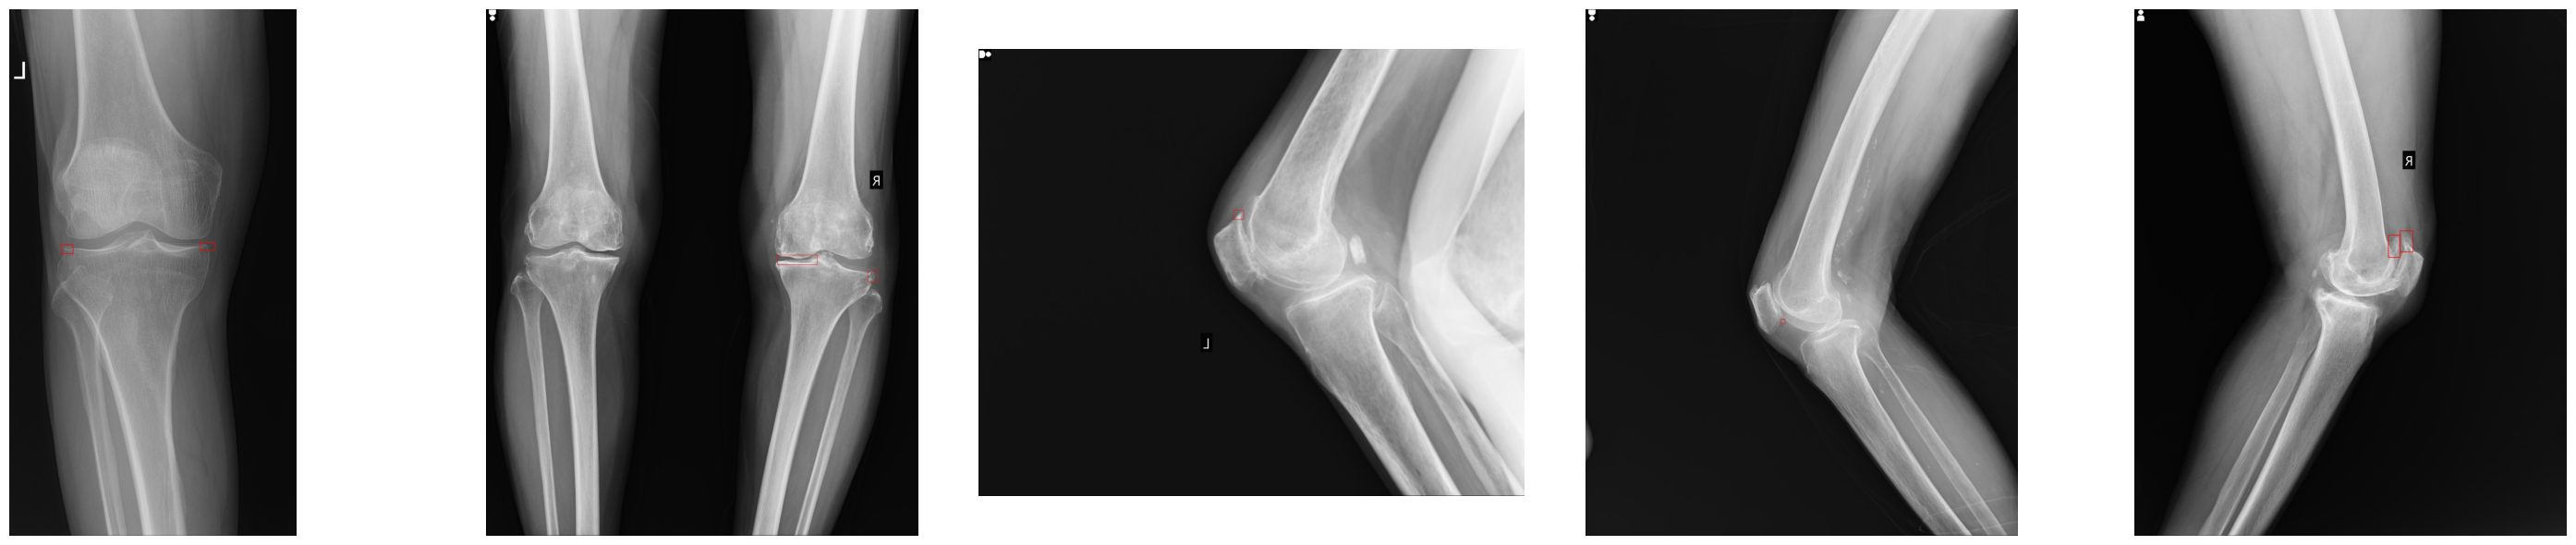

In [ ]:
# # Gọi hàm để hiển thị ảnh
show_random_images(Config.AUGMENT_IMAGES, Config.AUGMENT_LABELS)

In [ ]:
# Di chuyển dữ liệu tăng cường vào folder data gốc
move_folders(Config.AUGMENT_IMAGES, Config.AUGMENT_LABELS, Config.IMAGES_DIR, Config.LABELS_DIR_RM_CLASS)

In [ ]:
# Số lượng sau tăng cường
label_counts_goc_aug = count_labels(Config.LABELS_DIR_RM_CLASS, Config.LABELS_NAME)
print("Số lượng mãu cho từng nhãn ban đầu + nhãn tăng cường:", label_counts_goc_aug)

Số lượng mãu cho từng nhãn ban đầu + nhãn tăng cường: {'lv_1': 1367, 'lv_2': 1368, 'lv_3': 1369, 'lv_4': 1368}


In [ ]:
# Thực hiện các bước tiền xử lý dữ liệu
preprocess_data(Config.IMAGES_DIR, Config.LABELS_DIR_RM_CLASS,
                Config.PROCESSING_IMAGES_DIR, Config.PROCESSING_LABELS_DIR,
                target_size=(640, 640))

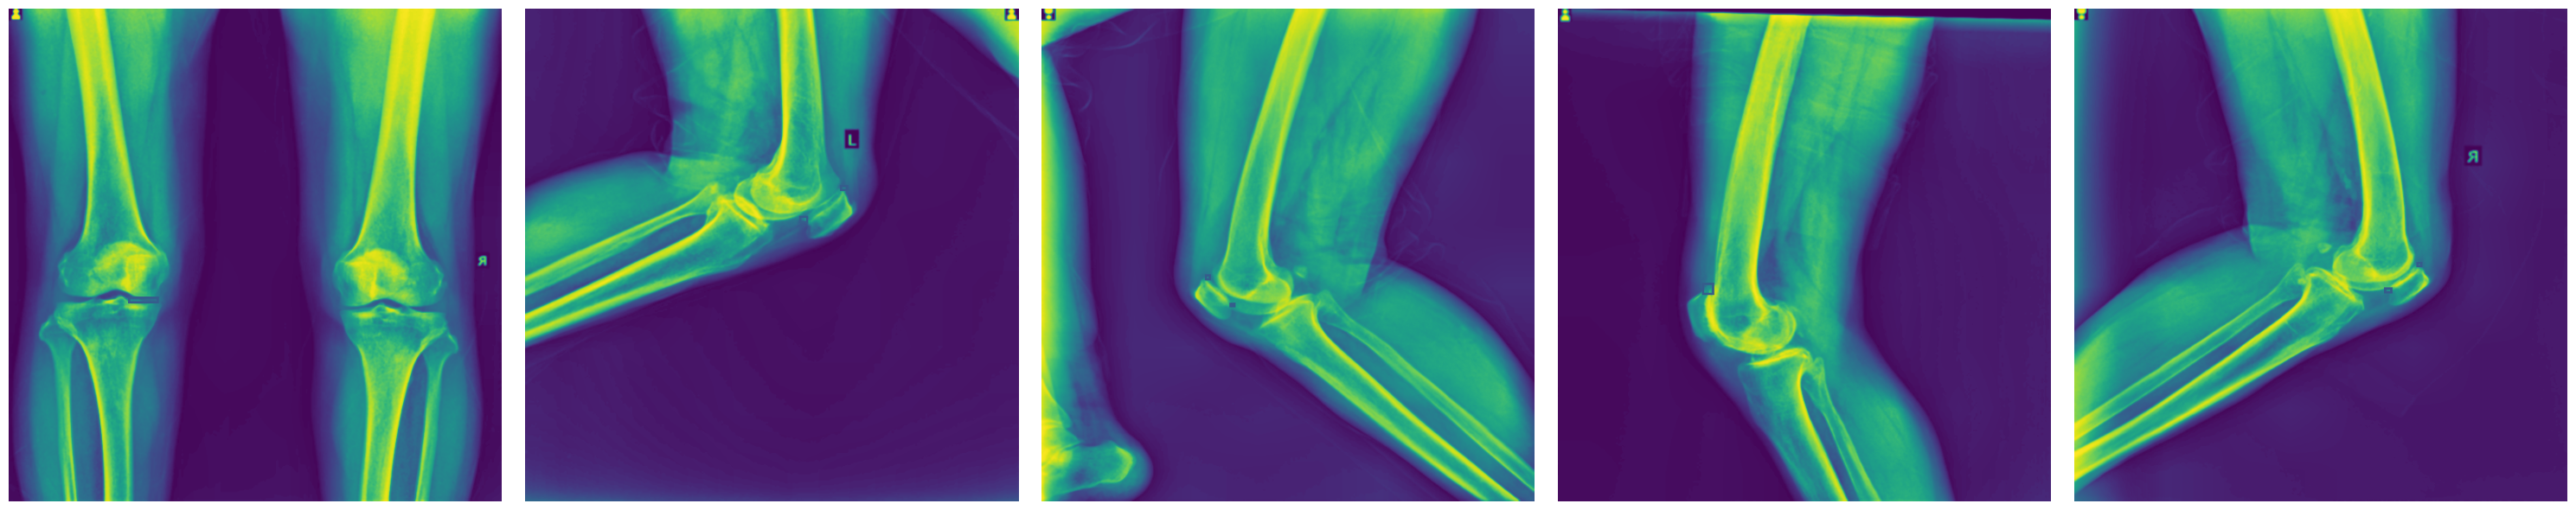

In [ ]:
# Gọi hàm để hiển thị ảnh
show_random_images(Config.PROCESSING_IMAGES_DIR, Config.PROCESSING_LABELS_DIR)

In [ ]:
# Chia dữ liệu
data_split(images_dir=Config.IMAGES_DIR,
           labels_dir=Config.LABELS_DIR_RM_CLASS,
           folder_train_img=Config.FOLDER_TRAIN_IMG,
           folder_val_img=Config.FOLDER_VAL_IMG,
           folder_test_img=Config.FOLDER_TEST_IMG,
            folder_train_lab=Config.FOLDER_TRAIN_LAB,
            folder_val_lab=Config.FOLDER_VAL_LAB,
            folder_test_lab=Config.FOLDER_TEST_LAB)

# Xây dựng mô hình YOLOv11

### Huấn luyện mô hình YOLO

In [32]:
import os
import yaml

# Tạo file custom_data.yaml cho YOLO
data = dict(
    train=os.path.abspath(Config.FOLDER_TRAIN_PATH),
    val=os.path.abspath(Config.FOLDER_VAL_PATH),
    test=os.path.abspath(Config.FOLDER_TEST_PATH),
    nc=len(Config.LABELS_NAME),
    names=Config.LABELS_NAME
)

# Tạo thư mục nếu nó chưa tồn tại
os.makedirs(os.path.dirname(Config.DATA_CUSTOM), exist_ok=True)

with open(Config.DATA_CUSTOM, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print(f"Created custom_data.yaml at {Config.DATA_CUSTOM}")

Created custom_data.yaml at ./weight/custom_data.yaml


In [33]:
train_yolo(Config.WEIGHT_YOLO, Config.DATA_CUSTOM)

engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./weight/custom_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./weight/yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False,

OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 48.12 MiB is free. Process 7627 has 14.69 GiB memory in use. Of the allocated memory 14.38 GiB is allocated by PyTorch, and 159.15 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# fineturning_weight = '/content/drive/MyDrive/BoYTe/runs/detect/train/weights/best.pt'

# train_yolo(fineturning_weight, Config.DATA_CUSTOM)

### Đánh giá mô hình

In [ ]:
# Đường dẫn file .yaml
train_dir, val_dir, test_dir, num_classes, class_names = load_yaml_config(Config.DATA_CUSTOM)

print(f"Validation Dataset: {val_dir}")
print(f"Number of Classes: {num_classes}")
print(f"Class Names: {class_names}")

In [ ]:
# Load model YOLO
weight_model_path = '/content/drive/MyDrive/Job/KneeOA//runs/detect/train3/weights/best.pt'
results_predict = load_weight_model(weight_model_path, val_dir)


image 1/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20221215.140247.1030579.jpg: 640x544 1 knee, 56.7ms
image 2/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230725.135040.1039497.jpg: 640x544 1 knee, 45.8ms
image 3/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230825.143117.1063824.jpg: 640x544 3 knees, 45.6ms
image 4/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230906.153955.1072284.jpg: 640x544 2 knees, 43.9ms
image 5/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230907.140803.1073185.jpg: 640x544 1 knee, 43.9ms
image 6/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230907.143142.1073238.jpg: 640x544 2 knees, 43.8ms
image 7/11 /content/drive/MyDrive/BoYTe/Detect_KNEE/val/images/1.2.392.200036.9107.307.24972.20230910.130556.1075343.jpg: 640x

In [ ]:
# Nhãn ground truth
gt_labels = read_labels(os.path.join(val_dir.replace('images', 'labels')))

# Nhãn dự đoán
pred_label_dir = '/content/drive/MyDrive/BoYTe/runs/detect/predict2/labels'
pred_labels = read_labels(pred_label_dir)

# Đánh giá mô hình
precision, recall, f1_score = evaluate_yolo_metrics(gt_labels, pred_labels, iou_threshold=0.5)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")

Precision: 0.82
Recall: 1.00
F1 Score: 0.90


In [ ]:
# Load model đã huấn luyện
model = YOLO('/content/drive/MyDrive/BoYTe/runs/detect/train2/weights/best.pt')  # Model đã được huấn luyện

# Đánh giá trên tập test
results = model.val(data=Config.DATA_CUSTOM, split='test')

# In kết quả
print(results)


Ultralytics 8.3.55 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv9c summary (fused): 384 layers, 25,323,103 parameters, 0 gradients, 102.3 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 104MB/s]
val: Scanning /content/drive/MyDrive/BoYTe/Data_Chuan/test/labels... 636 images, 0 backgrounds, 0 corrupt: 100%|██████████| 636/636 [00:43<00:00, 14.65it/s]


val: New cache created: /content/drive/MyDrive/BoYTe/Data_Chuan/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [09:23<00:00, 14.08s/it]


                   all        636       1136      0.699      0.703      0.709        0.6
                     0        137        198      0.813      0.803      0.836      0.803
                     1        186        248      0.814      0.831      0.879      0.728
                     2        145        233      0.335      0.283      0.233     0.0924
                     3        149        253      0.686      0.688      0.699      0.584
                     4        101        204       0.85      0.912        0.9      0.792
Speed: 2.0ms preprocess, 859.6ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b96440a27d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_result

# Kiểm thử mô hình

In [ ]:
# Load the YOLO model
model_path = "/content/drive/MyDrive/BoYTe/runs/detect/train/weights/last.pt"
model = YOLO(model_path)

# Predict using the YOLO model
image = '/content/drive/MyDrive/BoYTe/Data_Chuan/test/images/9003175_1.png'
model.predict(source=image, save=True, save_txt=False, stream=False)